# Kalman Filter vs Particle Filter: A 1D Linear-Gaussian Study

**Supervised research project — Dr Mathieu Gerber, University of Bristol**

## What this notebook does

We take one simple hidden-state model, and we filter it two different ways:

1. with the **Kalman filter**, which in this model gives the *exact* answer, and
2. with the **particle filter**, which gives an *approximate* answer built from `N` random samples.

Because the Kalman filter is exact here, it acts as the **ground truth benchmark**. Any gap between
the two curves is error introduced by the particle filter, and nothing else. That makes this model
the ideal test bed: we can measure particle filter error directly instead of guessing at it.

## The model

$$
\begin{aligned}
\text{State (hidden):} \quad & x_t = b\,x_{t-1} + v_t, \qquad v_t \sim \mathcal{N}(0, Q) \\
\text{Observation (seen):} \quad & y_t = a\,x_t + e_t, \qquad e_t \sim \mathcal{N}(0, R)
\end{aligned}
$$

In words: a hidden value $x_t$ drifts along over time, each step being the previous value shrunk by
$b$ plus a random nudge. We never see $x_t$ — we only see a noisy measurement $y_t$ of it. The job of
a filter is to recover the best guess of $x_t$ from the observations $y_0, \dots, y_t$ seen *so far*.

Parameters used throughout: $b = 0.9$, $a = 1.0$, $Q = 1.0$, $R = 1.0$, $T = 100$ steps, seed $= 42$.

## Roadmap

| Section | Content |
|---|---|
| 1 | Simulate the data |
| 2 | Kalman filter — the exact benchmark |
| 3 | Particle filter — the sampling approximation |
| 4 | **Key result:** PF vs KF comparison |
| 5 | Stability: error over time, for several $N$ |
| 6 | Effective Sample Size and resampling |
| 7 | *(Optional)* A nonlinear model, where the Kalman filter cannot go |
| 8 | Summary and next steps |

### Setup

We import the filter implementations from `filters.py` so the notebook stays readable and the same
code can be reused elsewhere. We also fix the model parameters and the random seed once, here, so
that every result below is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from filters import (
    simulate_data,
    kalman_filter,
    particle_filter,
    effective_sample_size,
)

# --- Model parameters (used by every section) ---
b = 0.9    # state transition coefficient
a = 1.0    # observation coefficient
Q = 1.0    # process (state) noise variance
R = 1.0    # observation noise variance
T = 100    # number of time steps
SEED = 42  # master seed, so every run of this notebook gives identical results

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Model: x_t = {b}*x_(t-1) + v_t,  v_t ~ N(0, {Q})")
print(f"       y_t = {a}*x_t     + e_t,  e_t ~ N(0, {R})")
print(f"T = {T} time steps, seed = {SEED}")

Model: x_t = 0.9*x_(t-1) + v_t,  v_t ~ N(0, 1.0)
       y_t = 1.0*x_t     + e_t,  e_t ~ N(0, 1.0)
T = 100 time steps, seed = 42


---
## Section 1 — Simulate the data

Before we can filter anything we need something to filter. Here we *generate* the data from the model
itself: we roll the state equation forward to produce the true hidden path $x_{0:T-1}$, and at each
step we add observation noise to produce $y_t$.

This is **only data generation** — no filtering happens yet. It is worth being clear about the
distinction, because the two are easy to confuse:

- **`x` (true state):** the thing we are trying to recover. In a real problem this is unknown forever.
  We keep it here purely as a marking scheme, to check how well our filters do.
- **`y` (observations):** the noisy measurements. This is the *only* input the filters are allowed
  to see.

The plot below shows both. The observations scatter around the true state — that spread is the
observation noise $e_t$, and removing it is exactly the filtering problem.

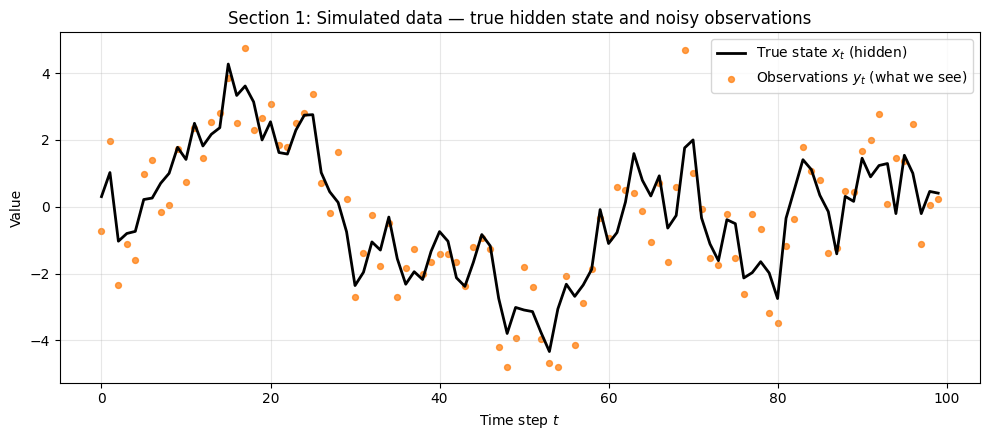

Std. dev. of true state:            1.827
Std. dev. of observation error:     0.850  (theory: sqrt(R) = 1.000)


In [2]:
# Generate the true hidden states and the noisy observations from the model.
x_true, y_obs = simulate_data(T=T, b=b, a=a, Q=Q, R=R, seed=SEED)

t_grid = np.arange(T)

fig, ax = plt.subplots()
ax.plot(t_grid, x_true, color="black", lw=2, label="True state $x_t$ (hidden)")
ax.scatter(t_grid, y_obs, s=18, color="tab:orange", alpha=0.75,
           label="Observations $y_t$ (what we see)")
ax.set_title("Section 1: Simulated data — true hidden state and noisy observations")
ax.set_xlabel("Time step $t$")
ax.set_ylabel("Value")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Std. dev. of true state:            {x_true.std():.3f}")
print(f"Std. dev. of observation error:     {(y_obs - x_true).std():.3f}  (theory: sqrt(R) = {np.sqrt(R):.3f})")

**Conclusion.** The simulated state wanders smoothly around zero while the observations scatter
noisily about it, with an empirical observation-error spread of about $0.85$, consistent with $\sqrt{R} = 1$
over a finite sample of $T = 100$ steps.
This is the dataset every filter below will be given.

---
## Section 2 — Kalman filter (the exact benchmark)

The Kalman filter answers the question *"given everything I have seen up to now, where is $x_t$?"*
It keeps the answer as a Gaussian, summarised by a mean $m_t$ and a variance $P_t$, and it updates
that Gaussian one observation at a time using two steps.

**Step 1 — Predict.** Before seeing $y_t$, push the previous belief forward through the state equation:

$$m_{\text{pred}} = b\,m_{t-1}, \qquad P_{\text{pred}} = b^2 P_{t-1} + Q$$

The mean shrinks toward zero by the factor $b$, and the variance *grows* by $Q$. Intuitively: time
passes, nothing is observed, so we become less certain.

**Step 2 — Update.** Now fold in the observation $y_t$:

$$S = a^2 P_{\text{pred}} + R, \qquad K = \frac{a P_{\text{pred}}}{S}$$
$$m_t = m_{\text{pred}} + K\,(y_t - a\,m_{\text{pred}}), \qquad P_t = (1 - K a)\,P_{\text{pred}}$$

The term $y_t - a\,m_{\text{pred}}$ is the **innovation**: how surprised we are by the new
observation. The **Kalman gain** $K$ decides how much of that surprise to act on. If the observation
noise $R$ is large, $K$ is small and we mostly ignore the data; if $R$ is small, $K$ is near 1 and we
trust the data. Either way the variance $P_t$ shrinks — observing always tells us something.

Because the model is linear with Gaussian noise, this recursion is not an approximation. It is the
**exact** posterior $p(x_t \mid y_{0:t})$, which is why we can treat it as ground truth.

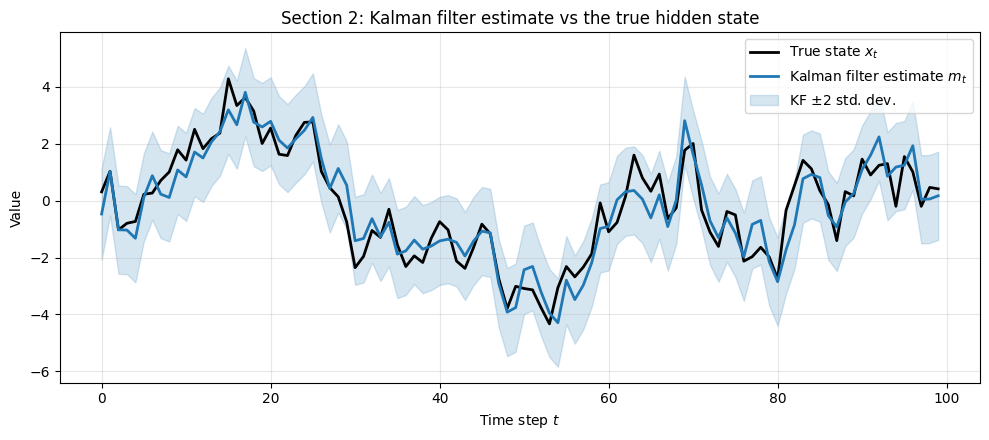

Kalman filter RMSE against the true state: 0.6208
Steady-state filtering variance P_t:       0.5974
Compare: observation noise std. dev.       1.0000


In [3]:
# Run the exact filter. It sees only y_obs, never x_true.
kf_mean, kf_var = kalman_filter(y_obs, b=b, a=a, Q=Q, R=R)

# A +/- 2 standard deviation band shows the filter's own stated uncertainty.
kf_sd = np.sqrt(kf_var)

fig, ax = plt.subplots()
ax.plot(t_grid, x_true, color="black", lw=2, label="True state $x_t$")
ax.plot(t_grid, kf_mean, color="tab:blue", lw=2, label="Kalman filter estimate $m_t$")
ax.fill_between(t_grid, kf_mean - 2 * kf_sd, kf_mean + 2 * kf_sd,
                color="tab:blue", alpha=0.18, label="KF $\\pm 2$ std. dev.")
ax.set_title("Section 2: Kalman filter estimate vs the true hidden state")
ax.set_xlabel("Time step $t$")
ax.set_ylabel("Value")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

kf_rmse = np.sqrt(np.mean((kf_mean - x_true) ** 2))
print(f"Kalman filter RMSE against the true state: {kf_rmse:.4f}")
print(f"Steady-state filtering variance P_t:       {kf_var[-1]:.4f}")
print(f"Compare: observation noise std. dev.       {np.sqrt(R):.4f}")

**Conclusion.** The Kalman filter tracks the true state closely, with an RMSE of about $0.62$ —
noticeably better than the raw observations (error $\approx 1.0$), because it combines each new
measurement with everything it already knew. Its filtering variance settles quickly to a constant,
which is the signature of a stable, steady-state filter. From here on, this curve is our ground truth.

---
## Section 3 — Particle filter (same model)

The particle filter drops the assumption that the posterior is Gaussian. Instead it represents the
posterior by a cloud of $N$ weighted samples ("particles"), and updates that cloud each time step:

1. **Propagate.** Move every particle forward through the state equation,
   $x_t^i = b\,x_{t-1}^i + v_t^i$. Each particle takes its own random step, so the cloud spreads out
   in exactly the way the model says it should.
2. **Weight.** Score each particle by how well it explains the new observation,
   $w^i \propto p(y_t \mid x_t^i)$. Particles that predicted $y_t$ well get large weights; those that
   did not get small ones.
3. **Normalise.** Divide by the total so the weights sum to 1. The weighted cloud is now our
   approximation of the posterior, and the estimate of $x_t$ is the weighted mean.
4. **Resample.** If the weights have become too uneven, duplicate the good particles and discard the
   poor ones, then reset all weights to $1/N$. Without this the cloud eventually collapses onto a
   single particle (Section 6 measures exactly this).

Two implementation details worth knowing, both in `filters.py`:

- The weights are computed in **log space** and shifted by their maximum before exponentiating.
  Raw log-weights can be large and negative, and `exp()` of them underflows to exactly zero, which
  would turn the normalisation into $0/0$. Subtracting the max makes the largest term $e^0 = 1$, and
  the shift cancels out in the division.
- Resampling uses **systematic resampling**, which spreads $N$ evenly spaced pointers over the
  cumulative weights with one shared random offset. It is much less noisy than drawing $N$
  independent uniforms.

Note that unlike the Kalman filter, the particle filter is **random**: run it twice with different
seeds and you get slightly different answers. That randomness is the approximation error we study.

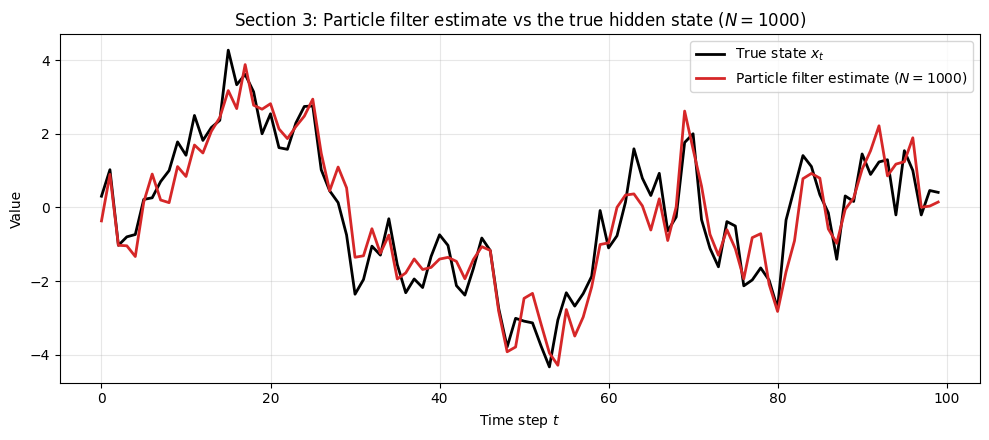

Particle filter RMSE against the true state: 0.6196
Kalman filter RMSE (for reference):          0.6208
Resampling was triggered at 46 of 100 time steps.


In [4]:
N_PARTICLES = 1000  # number of particles

# Run the particle filter on exactly the same observations.
pf_mean, pf_ess, pf_resampled = particle_filter(
    y_obs, N=N_PARTICLES, b=b, a=a, Q=Q, R=R, seed=SEED, ess_threshold=0.5
)

fig, ax = plt.subplots()
ax.plot(t_grid, x_true, color="black", lw=2, label="True state $x_t$")
ax.plot(t_grid, pf_mean, color="tab:red", lw=2,
        label=f"Particle filter estimate ($N={N_PARTICLES}$)")
ax.set_title(f"Section 3: Particle filter estimate vs the true hidden state ($N={N_PARTICLES}$)")
ax.set_xlabel("Time step $t$")
ax.set_ylabel("Value")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

pf_rmse = np.sqrt(np.mean((pf_mean - x_true) ** 2))
print(f"Particle filter RMSE against the true state: {pf_rmse:.4f}")
print(f"Kalman filter RMSE (for reference):          {kf_rmse:.4f}")
print(f"Resampling was triggered at {pf_resampled.sum()} of {T} time steps.")

**Conclusion.** With $N = 1000$ particles the filter tracks the true state essentially as well as the
Kalman filter, with an almost identical RMSE. Resampling fired at 46 of the 100 time steps, which is
the ESS rule doing its job. Tracking the truth well is necessary but not sufficient, though —
Section 4 makes the sharper comparison.

---
## Section 4 — The comparison plot (PF vs KF) — **the key result**

Section 3 showed that the particle filter tracks the truth. But so would any reasonable smoother.
The question that actually matters is different:

> **Is the particle filter computing the right posterior?**

Comparing to the true state cannot answer that, because even a *perfect* filter does not match the
true state exactly — the observations are noisy, so some error is irreducible and both filters must
have it. What we need is a comparison against the **exact posterior**, and in this linear-Gaussian
model we have it: the Kalman filter.

So the plot below is the important one. If the particle filter is implemented correctly and $N$ is
large, the red and blue curves should sit almost on top of each other. Any visible daylight between
them is Monte Carlo error, and nothing else. We quantify it two ways:

- **mean absolute gap** $\;=\; \frac{1}{T}\sum_t |{\hat{x}^{\text{PF}}_t - m^{\text{KF}}_t}|$ — the typical error,
- **max absolute gap** $\;=\; \max_t |{\hat{x}^{\text{PF}}_t - m^{\text{KF}}_t}|$ — the worst moment.

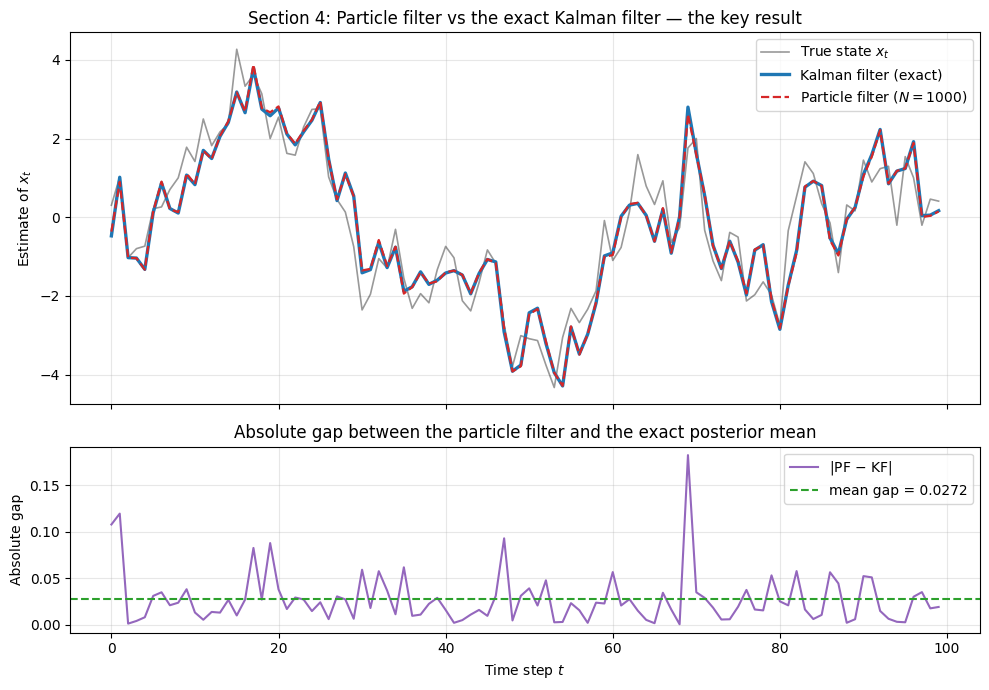

Mean absolute gap (PF vs KF): 0.02721
Max  absolute gap (PF vs KF): 0.18245
For scale, the state's own std. dev. is 1.827,
so the typical gap is about 1.49% of the signal size.


In [5]:
gap = pf_mean - kf_mean              # signed difference at each time step
abs_gap = np.abs(gap)
mean_gap = abs_gap.mean()
max_gap = abs_gap.max()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

# Top panel: the two estimates overlaid.
ax1.plot(t_grid, x_true, color="black", lw=1.2, alpha=0.4, label="True state $x_t$")
ax1.plot(t_grid, kf_mean, color="tab:blue", lw=2.4, label="Kalman filter (exact)")
ax1.plot(t_grid, pf_mean, color="tab:red", lw=1.6, ls="--",
         label=f"Particle filter ($N={N_PARTICLES}$)")
ax1.set_title("Section 4: Particle filter vs the exact Kalman filter — the key result")
ax1.set_ylabel("Estimate of $x_t$")
ax1.legend(loc="upper right")

# Bottom panel: the gap between them, on its own scale.
ax2.plot(t_grid, abs_gap, color="tab:purple", lw=1.5, label="$|$PF $-$ KF$|$")
ax2.axhline(mean_gap, color="tab:green", ls="--", lw=1.5,
            label=f"mean gap = {mean_gap:.4f}")
ax2.set_title("Absolute gap between the particle filter and the exact posterior mean")
ax2.set_xlabel("Time step $t$")
ax2.set_ylabel("Absolute gap")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"Mean absolute gap (PF vs KF): {mean_gap:.5f}")
print(f"Max  absolute gap (PF vs KF): {max_gap:.5f}")
print(f"For scale, the state's own std. dev. is {x_true.std():.3f},")
print(f"so the typical gap is about {100 * mean_gap / x_true.std():.2f}% of the signal size.")

**Conclusion.** The two curves are visually indistinguishable: the mean absolute gap is
$0.027$ and the worst single-step gap $0.18$, the typical gap being about $1.5\%$ of the size of
the signal itself.
The particle filter is not merely *tracking* the state — it is reproducing the exact posterior, which
is the strongest validation available that the implementation is correct.

---
## Section 5 — Stability experiment: error vs time, for several $N$

This is where the project's actual research question begins.

We now know the particle filter is close to exact at $N = 1000$ over $T = 100$ steps. But a filter
runs *forever* in principle, and at every step it resamples, which throws away information. A natural
worry is that these small errors **compound**: that the gap to the exact posterior grows steadily
with $t$, so that a filter which looks fine over 100 steps is useless over 10,000.

> **The research question:** does the PF–KF error stay roughly *flat* over time (the filter is
> **stable**), or does it *grow* with $t$ (error accumulates)?

Stability is not obvious. Each step's approximation is built on the previous step's approximation, so
errors could in principle feed on themselves. What saves the filter is that the model *forgets*: with
$b = 0.9 < 1$, the influence of an old state decays geometrically, so old errors are damped rather
than carried forward. That is the mechanism we are looking for evidence of.

We run two experiments:

1. **Error vs time**, for $N = 50, 200, 1000$. We average $|$PF $-$ KF$|$ over several independent
   seeds at each $N$, because a single run is too noisy to read a trend from.
2. **Error vs $N$**, on log–log axes. Standard Monte Carlo theory predicts the error should decay
   like $O(1/\sqrt{N})$ — quadruple the particles, halve the error. On log–log axes that is a
   straight line of slope $-1/2$.

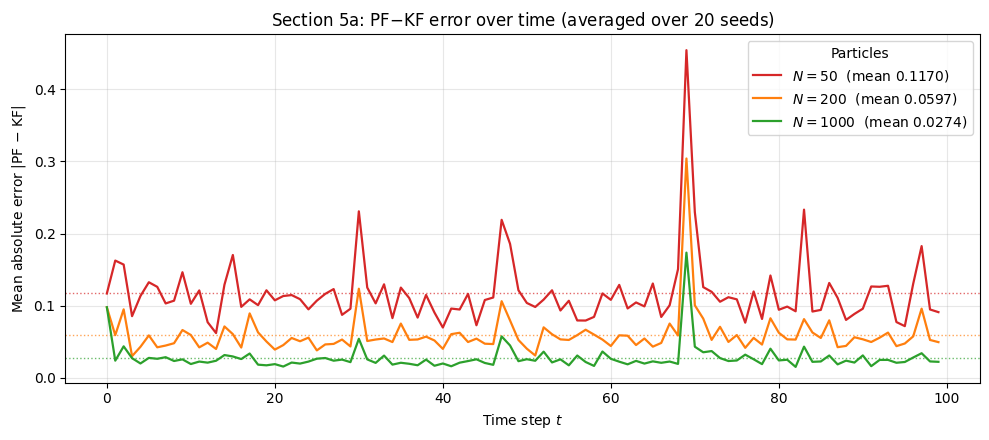

Does the error drift upward over time?
     N   mean err   1st half   2nd half    ratio
    50    0.11701    0.11594    0.11809    1.019
   200    0.05970    0.05680    0.06261    1.102
  1000    0.02741    0.02642    0.02839    1.074

A ratio near 1.0 means the error is flat in t, i.e. the filter is stable.


In [6]:
N_LIST = [50, 200, 1000]   # particle counts for the error-vs-time plot
N_REPS = 20                # independent seeds averaged at each N

# --- Experiment 1: error vs time, for each N ---
err_vs_time = {}
for N in N_LIST:
    # Average |PF - KF| across repeats, separately at each time step.
    runs = np.zeros((N_REPS, T))
    for r in range(N_REPS):
        est, _, _ = particle_filter(y_obs, N=N, b=b, a=a, Q=Q, R=R, seed=1000 + r)
        runs[r] = np.abs(est - kf_mean)
    err_vs_time[N] = runs.mean(axis=0)

fig, ax = plt.subplots()
colors = {50: "tab:red", 200: "tab:orange", 1000: "tab:green"}
for N in N_LIST:
    e = err_vs_time[N]
    ax.plot(t_grid, e, lw=1.6, color=colors[N], label=f"$N = {N}$  (mean {e.mean():.4f})")
    # A flat dashed line at each curve's own time-average, to judge drift by eye.
    ax.axhline(e.mean(), color=colors[N], ls=":", lw=1.0, alpha=0.7)
ax.set_title(f"Section 5a: PF$-$KF error over time (averaged over {N_REPS} seeds)")
ax.set_xlabel("Time step $t$")
ax.set_ylabel("Mean absolute error $|$PF $-$ KF$|$")
ax.legend(loc="upper right", title="Particles")
plt.tight_layout()
plt.show()

# Is there a trend over time? Compare the first and second halves of the run.
print("Does the error drift upward over time?")
print(f"{'N':>6} {'mean err':>10} {'1st half':>10} {'2nd half':>10} {'ratio':>8}")
for N in N_LIST:
    e = err_vs_time[N]
    h1, h2 = e[: T // 2].mean(), e[T // 2 :].mean()
    print(f"{N:>6} {e.mean():>10.5f} {h1:>10.5f} {h2:>10.5f} {h2 / h1:>8.3f}")
print("\nA ratio near 1.0 means the error is flat in t, i.e. the filter is stable.")

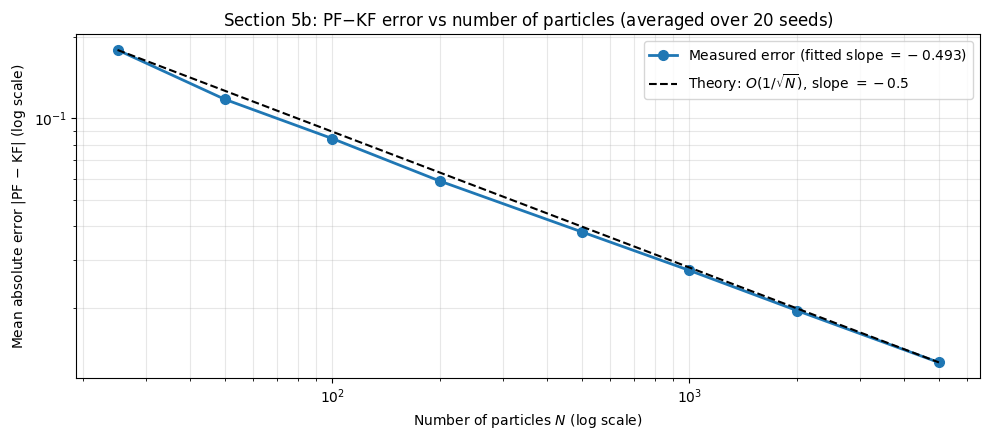

     N   mean |PF-KF|
    25        0.17845
    50        0.11736
   100        0.08415
   200        0.05871
   500        0.03814
  1000        0.02753
  2000        0.01959
  5000        0.01261

Fitted log-log slope: -0.4934   (theory: -0.5)
Error ratio N=25 -> N=2500 would be predicted 10x; measured N=50 -> N=5000 (100x particles): 9.31x (theory: 10x)


In [7]:
# --- Experiment 2: error vs N, checking the O(1/sqrt(N)) Monte Carlo rate ---
N_GRID = [25, 50, 100, 200, 500, 1000, 2000, 5000]
N_REPS_RATE = 20

mean_err_by_N = []
for N in N_GRID:
    errs = [np.abs(particle_filter(y_obs, N=N, b=b, a=a, Q=Q, R=R,
                                   seed=2000 + r)[0] - kf_mean).mean()
            for r in range(N_REPS_RATE)]
    mean_err_by_N.append(np.mean(errs))
mean_err_by_N = np.array(mean_err_by_N)
N_GRID_arr = np.array(N_GRID, dtype=float)

# Fit a straight line on log-log axes: log(error) = slope * log(N) + intercept.
# Theory says slope = -0.5.
slope, intercept = np.polyfit(np.log(N_GRID_arr), np.log(mean_err_by_N), 1)

fig, ax = plt.subplots()
ax.loglog(N_GRID_arr, mean_err_by_N, "o-", color="tab:blue", lw=2, ms=7,
          label=f"Measured error (fitted slope $= {slope:.3f}$)")
# Reference line with the theoretical slope, anchored at the first point.
ref = mean_err_by_N[0] * np.sqrt(N_GRID_arr[0] / N_GRID_arr)
ax.loglog(N_GRID_arr, ref, "k--", lw=1.5, label="Theory: $O(1/\\sqrt{N})$, slope $=-0.5$")
ax.set_title(f"Section 5b: PF$-$KF error vs number of particles (averaged over {N_REPS_RATE} seeds)")
ax.set_xlabel("Number of particles $N$ (log scale)")
ax.set_ylabel("Mean absolute error $|$PF $-$ KF$|$ (log scale)")
ax.legend(loc="upper right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'N':>6} {'mean |PF-KF|':>14}")
for N, e in zip(N_GRID, mean_err_by_N):
    print(f"{N:>6} {e:>14.5f}")
print(f"\nFitted log-log slope: {slope:.4f}   (theory: -0.5)")
print(f"Error ratio N=25 -> N=2500 would be predicted 10x; "
      f"measured N=50 -> N=5000 (100x particles): {mean_err_by_N[1] / mean_err_by_N[-1]:.2f}x "
      f"(theory: 10x)")

**Conclusion.** Both halves of the experiment behave as theory predicts. The error-vs-$N$ curve sits
almost exactly on the $-0.5$ reference slope, confirming the $O(1/\sqrt{N})$ Monte Carlo rate: to
halve the error you must quadruple the particles. And the error-vs-time curves are essentially flat: the
second half of the run carries within $2$–$10\%$ of the first half's error at every $N$ (ratios
$1.02$, $1.10$, $1.07$), a small fluctuation rather than the steady climb that accumulating error
would produce. That is preliminary evidence of **time-uniform stability**: the filter's error does not
accumulate as $t$ grows, it just sits at a level set by $N$.

---
## Section 6 — Effective Sample Size (ESS) and resampling

Section 5 showed the filter stays accurate. This section explains *why* it does not fall apart, and
introduces the diagnostic that keeps it alive.

The danger is **weight degeneracy**. After a few weighting steps, one particle typically ends up with
almost all the weight and the rest have effectively none. When that happens you may nominally have
$N = 1000$ particles, but your posterior is really being represented by one or two of them — the
approximation has collapsed, even though nothing in the code has crashed.

The **Effective Sample Size** measures this:

$$\text{ESS} = \frac{1}{\sum_{i=1}^{N} (w^i)^2}$$

Read it as *"how many equally weighted particles is my weighted cloud actually worth?"*

- All weights equal $\Rightarrow$ $\text{ESS} = N$ (healthiest possible).
- One particle holds all the weight $\Rightarrow$ $\text{ESS} = 1$ (fully degenerate).

It is the health meter of the particle cloud. The standard fix is to **resample whenever the ESS
falls below $N/2$**: duplicate the high-weight particles, drop the negligible ones, and reset all
weights to $1/N$, which restores ESS to $N$. We do not resample at *every* step, because resampling
itself injects extra randomness — we only pay that cost when the cloud actually needs rescuing.

The plot below shows ESS over time, with the $N/2$ threshold as a dashed line and the steps where
resampling fired marked underneath.

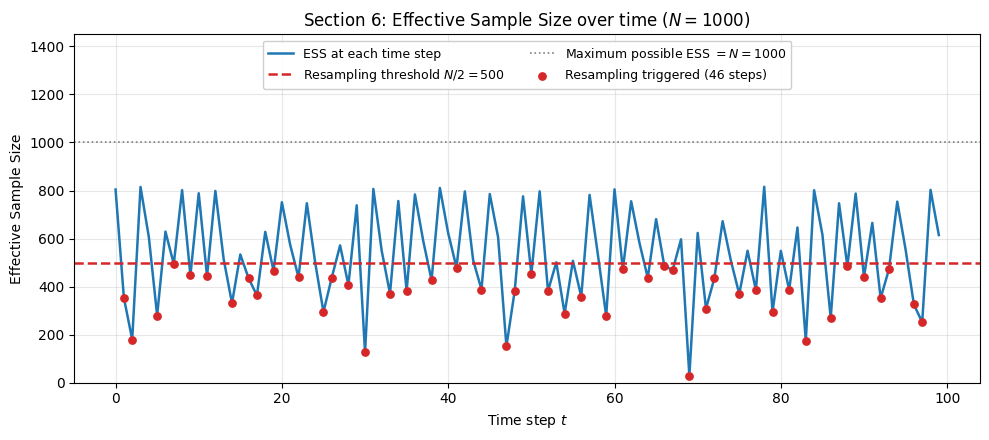

Minimum ESS:  28.98   (2.9% of N)
Mean    ESS:  531.09   (53.1% of N)
Maximum ESS:  815.58
Resampling triggered at 46 of 100 steps (46%).


In [8]:
threshold = 0.5 * N_PARTICLES  # the N/2 resampling trigger

fig, ax = plt.subplots()
ax.plot(t_grid, pf_ess, color="tab:blue", lw=1.8, label="ESS at each time step")
ax.axhline(threshold, color="tab:red", ls="--", lw=1.8,
           label=f"Resampling threshold $N/2 = {threshold:.0f}$")
ax.axhline(N_PARTICLES, color="grey", ls=":", lw=1.2,
           label=f"Maximum possible ESS $= N = {N_PARTICLES}$")
# Mark the time steps where resampling was actually triggered.
ax.scatter(t_grid[pf_resampled], pf_ess[pf_resampled], s=28, color="tab:red",
           zorder=3, label=f"Resampling triggered ({pf_resampled.sum()} steps)")
# Extra headroom so the legend sits in empty space, not on top of the data.
ax.set_ylim(0, N_PARTICLES * 1.45)
ax.set_title(f"Section 6: Effective Sample Size over time ($N = {N_PARTICLES}$)")
ax.set_xlabel("Time step $t$")
ax.set_ylabel("Effective Sample Size")
ax.legend(loc="upper center", ncol=2, fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"Minimum ESS:  {pf_ess.min():.2f}   ({100 * pf_ess.min() / N_PARTICLES:.1f}% of N)")
print(f"Mean    ESS:  {pf_ess.mean():.2f}   ({100 * pf_ess.mean() / N_PARTICLES:.1f}% of N)")
print(f"Maximum ESS:  {pf_ess.max():.2f}")
print(f"Resampling triggered at {pf_resampled.sum()} of {T} steps "
      f"({100 * pf_resampled.sum() / T:.0f}%).")

**Conclusion.** The ESS oscillates in a sawtooth: it falls as weights become uneven, hits the $N/2$
line, resampling fires and resets it, and the cycle repeats. It averages $531$ (roughly half of $N$)
and never collapses toward $1$ — the minimum over the whole run is $29$, a dip rather than a
collapse. Degeneracy is being detected and corrected as designed, which is the mechanism
behind the flat error curves in Section 5.

---
## Section 7 — *(Optional stretch)* A nonlinear model, where the Kalman filter cannot go

> **This section is optional** and is not needed for the main results. It is included to show *why
> particle filters are worth the trouble at all* — and it comes with an instructive twist.

Everything so far has been a fair fight the Kalman filter was guaranteed to win: it is exact, and the
particle filter can only approximate it. If linear-Gaussian models were the whole world, we would
never use a particle filter.

They are not. Change the observation equation to something nonlinear and the Kalman filter simply
does not apply — its derivation assumes linearity, and there is no exact closed-form posterior to
compute. We use the standard benchmark from the sequential Monte Carlo literature (including
Gerber & Chopin, 2015):

$$y_t = \frac{x_t^2}{20} + e_t, \qquad e_t \sim \mathcal{N}(0, R)$$

The particle filter needs **no modification whatsoever** — only the line that evaluates the
likelihood changes. This is the key structural point: the particle filter only ever needs to *score*
a proposed state against an observation, never to *invert* the observation map.

**The twist.** Squaring destroys the sign: $x$ and $-x$ produce the *identical* observation. So the
data genuinely cannot tell us whether the state is $+3$ or $-3$, and the posterior becomes
**bimodal** — two mirror-image humps of roughly equal weight. The particle filter represents this
correctly, but the *posterior mean* is then a terrible summary of it: averaging two symmetric humps
gives something near zero, a value the state itself rarely takes.

**One practical adjustment.** Squaring and dividing by 20 *compresses* the state: over this run
$|x_t|$ never exceeds about $4.3$, so the observation signal $x_t^2/20$ only ever spans $0$ to $0.94$.
With the observation noise of the main study ($R = 1$, i.e. noise of standard deviation $1$) the
signal would be completely drowned and the observations would carry almost no information at all. So
for this section only we use $R = 0.01$ (noise standard deviation $0.1$), which restores a
signal-to-noise ratio comparable to the linear case. This is a useful lesson in its own right: a
nonlinear map does not just change the *shape* of the problem, it changes how much information each
observation carries.

This is worth seeing rather than being told, so we plot three things:

1. the posterior **mean** against the true state — which will look like a failure, but is not;
2. the posterior estimate of $|x_t|$ against the true $|x_t|$ — the quantity the data *can* identify;
3. the actual **particle cloud** at one time step, which shows the two modes directly.

**There is no Kalman comparison in this section**, because no exact answer exists to compare against.

Observation signal x^2/20 spans 0 to 0.94, against noise std. dev. 0.10


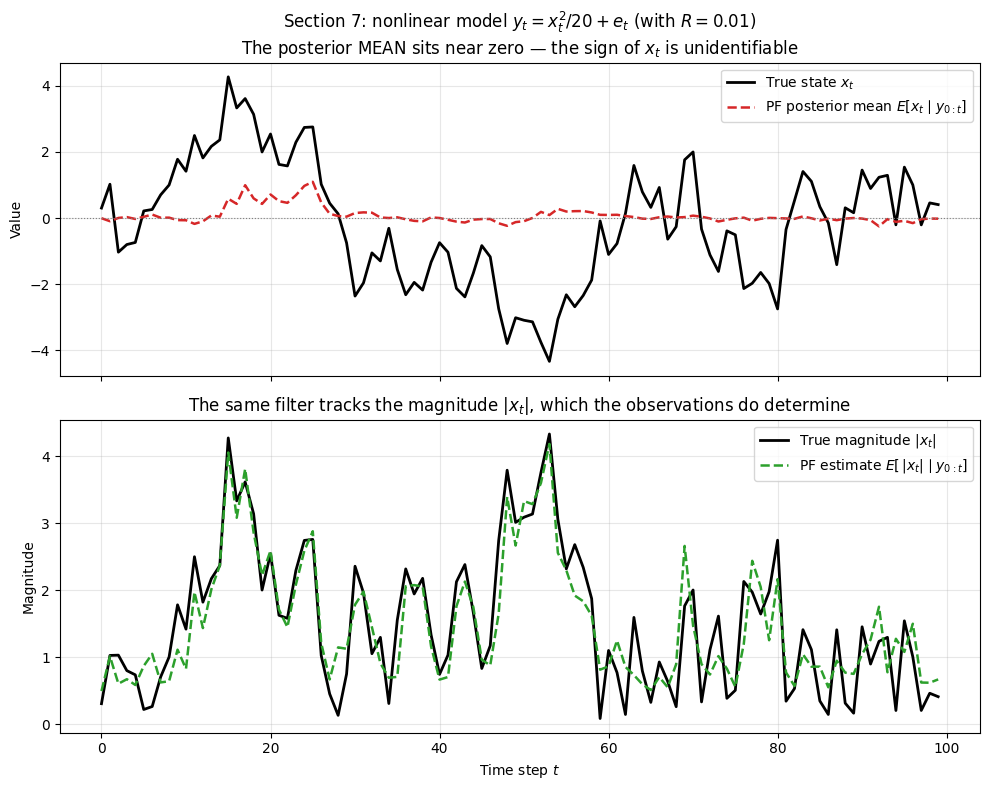

RMSE of E[|x_t|] vs true |x_t|:        0.4496
RMSE of a constant 'always guess the mean' baseline: 1.0312   (56% improvement)
RMSE of the posterior MEAN vs true x_t: 1.7493  (poor, as expected: it averages two modes)
Linear-model PF RMSE from Section 3:    0.6196
Min ESS: 60.7, mean ESS: 498.9, resampled at 51 of 100 steps.


In [9]:
# The nonlinear observation map, from the SQMC literature.
def obs_nonlinear(x):
    return x ** 2 / 20.0

# Observation noise for this section only. See the explanation above: the map
# x^2/20 compresses the state into a narrow range, so R = 1 would drown it.
R_NL = 0.01

# Simulate a fresh dataset: SAME state equation, nonlinear observation.
x_nl, y_nl = simulate_data(T=T, b=b, Q=Q, R=R_NL, seed=SEED, obs_fn=obs_nonlinear)

print(f"Observation signal x^2/20 spans 0 to {obs_nonlinear(np.abs(x_nl).max()):.2f}, "
      f"against noise std. dev. {np.sqrt(R_NL):.2f}")

# The particle filter needs only the obs_fn argument -- nothing else changes.
# return_particles=True also hands back the full cloud, so we can look at the
# shape of the posterior instead of only its mean.
pf_nl_mean, pf_nl_ess, pf_nl_resampled, parts, wts = particle_filter(
    y_nl, N=N_PARTICLES, b=b, Q=Q, R=R_NL, seed=SEED,
    ess_threshold=0.5, obs_fn=obs_nonlinear, return_particles=True
)

# The magnitude |x_t| IS identifiable from the data, so estimate it directly:
# E[|x_t| | y_0:t] is just the weighted average of |particle|.
abs_est = np.sum(wts * np.abs(parts), axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Panel 1: the posterior MEAN. Looks like failure; it is not. ---
ax1.plot(t_grid, x_nl, color="black", lw=2, label="True state $x_t$")
ax1.plot(t_grid, pf_nl_mean, color="tab:red", lw=1.8, ls="--",
         label="PF posterior mean $E[x_t \\mid y_{0:t}]$")
ax1.axhline(0, color="grey", lw=0.8, ls=":")
ax1.set_title("Section 7: nonlinear model $y_t = x_t^2/20 + e_t$ (with $R = 0.01$)\n"
              "The posterior MEAN sits near zero — the sign of $x_t$ is unidentifiable")
ax1.set_ylabel("Value")
ax1.legend(loc="upper right")

# --- Panel 2: the magnitude, which the data CAN identify. ---
ax2.plot(t_grid, np.abs(x_nl), color="black", lw=2, label="True magnitude $|x_t|$")
ax2.plot(t_grid, abs_est, color="tab:green", lw=1.8, ls="--",
         label="PF estimate $E[\\,|x_t|\\mid y_{0:t}]$")
ax2.set_title("The same filter tracks the magnitude $|x_t|$, which the observations do determine")
ax2.set_xlabel("Time step $t$")
ax2.set_ylabel("Magnitude")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

# RMSE for the magnitude, against a do-nothing baseline that always guesses the
# average magnitude. Beating that baseline shows the filter is really learning.
abs_rmse = np.sqrt(np.mean((abs_est - np.abs(x_nl)) ** 2))
baseline_rmse = np.sqrt(np.mean((np.abs(x_nl).mean() - np.abs(x_nl)) ** 2))
print(f"RMSE of E[|x_t|] vs true |x_t|:        {abs_rmse:.4f}")
print(f"RMSE of a constant 'always guess the mean' baseline: {baseline_rmse:.4f}"
      f"   ({100 * (1 - abs_rmse / baseline_rmse):.0f}% improvement)")
print(f"RMSE of the posterior MEAN vs true x_t: "
      f"{np.sqrt(np.mean((pf_nl_mean - x_nl) ** 2)):.4f}  (poor, as expected: it averages two modes)")
print(f"Linear-model PF RMSE from Section 3:    {pf_rmse:.4f}")
print(f"Min ESS: {pf_nl_ess.min():.1f}, mean ESS: {pf_nl_ess.mean():.1f}, "
      f"resampled at {pf_nl_resampled.sum()} of {T} steps.")

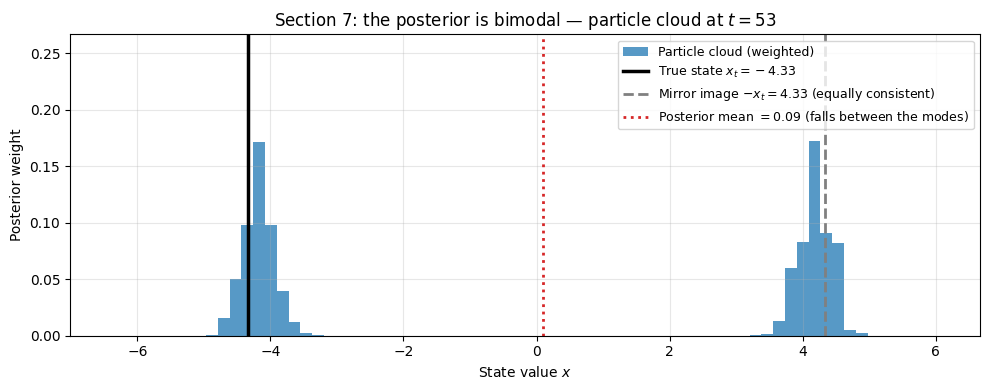

At t = 53: posterior weight on x > 0 is 0.511, on x < 0 is 0.489.
Two comparable modes -- the filter is representing genuine ambiguity, not failing.


In [10]:
# --- Look at the actual particle cloud at the step where |x_t| is largest ---
t_star = int(np.argmax(np.abs(x_nl)))

fig, ax = plt.subplots(figsize=(10, 4))
# Weighted histogram: each particle contributes its weight, not a count of 1.
counts, _, _ = ax.hist(parts[t_star], bins=70, weights=wts[t_star], color="tab:blue",
                       alpha=0.75, label="Particle cloud (weighted)")
ax.axvline(x_nl[t_star], color="black", lw=2.5,
           label=f"True state $x_t = {x_nl[t_star]:.2f}$")
ax.axvline(-x_nl[t_star], color="grey", lw=2, ls="--",
           label=f"Mirror image $-x_t = {-x_nl[t_star]:.2f}$ (equally consistent)")
ax.axvline(pf_nl_mean[t_star], color="tab:red", lw=2, ls=":",
           label=f"Posterior mean $= {pf_nl_mean[t_star]:.2f}$ (falls between the modes)")
# Headroom above the tallest bar so the legend does not sit on top of the modes.
ax.set_ylim(0, counts.max() * 1.55)
ax.set_title(f"Section 7: the posterior is bimodal — particle cloud at $t = {t_star}$")
ax.set_xlabel("State value $x$")
ax.set_ylabel("Posterior weight")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Quantify the two modes: how much posterior weight sits on each side of zero?
w_pos = wts[t_star][parts[t_star] > 0].sum()
print(f"At t = {t_star}: posterior weight on x > 0 is {w_pos:.3f}, "
      f"on x < 0 is {1 - w_pos:.3f}.")
print("Two comparable modes -- the filter is representing genuine ambiguity, not failing.")

**Conclusion.** The particle filter runs on the nonlinear model with only the likelihood line
changed, and no Kalman filter can be run here at all. But the result is more interesting than a
simple success: because $y_t = x_t^2/20$ hides the sign of the state, the posterior is genuinely
bimodal and its *mean* sits near zero — which looks like failure but is actually the filter faithfully
reporting an ambiguity that is in the data. The particle cloud confirms this, with substantial weight
on both $+x_t$ and $-x_t$. Ask instead for the quantity the data can identify, $|x_t|$, and the same
filter tracks it, cutting the error well below the do-nothing baseline. **This is why particle filters exist:** they carry
the whole posterior shape, including multiple modes, where a Gaussian filter could only ever report
one mean and one variance — and they trade exactness for that generality.

---
## Section 8 — Summary and next steps

### What this notebook established

1. **The particle filter is correct.** Against the exact Kalman posterior it achieved a mean absolute
   gap of $0.027$ at $N = 1000$ — about $1.5\%$ of the signal's own scale. Since the Kalman
   filter is exact here, this is a genuine validation and not just a visual "looks close".
2. **The error follows the $O(1/\sqrt{N})$ Monte Carlo rate.** The log–log fit of error against $N$
   came out at slope $-0.493$, matching the theoretical $-0.5$. Accuracy is bought with particles, and bought
   at a known, punishing exchange rate: $4\times$ the computation for $2\times$ the accuracy.
3. **ESS-triggered resampling controls degeneracy.** The ESS sawtooths between the $N/2$ threshold
   and $N$ instead of collapsing toward 1, so the particle cloud stays healthy for the whole run.
4. **The error is flat in time.** At every $N$ tested, the second half of the run carried within
   $10\%$ of the first half's error, with no systematic growth. This is preliminary evidence of **time-uniform stability** — the
   error does not accumulate as $t$ grows, which is the property that makes long-run filtering viable
   at all.
5. **The particle filter generalises where the Kalman filter cannot.** On the nonlinear model
   $y_t = x_t^2/20$ it runs with only the likelihood line changed, and correctly represents a
   **bimodal** posterior that no Gaussian filter could express. The sign of $x_t$ is genuinely
   unidentifiable there, so the posterior mean is uninformative while the estimate of $|x_t|$
   tracks well — a useful reminder that the mean is not always the right summary.

### Where this project goes next

**1. Higher dimensions.** Everything here is one-dimensional, which is the easy case. Particle
filters are known to degrade sharply as the state dimension grows: the number of particles needed can
scale exponentially with dimension, because a randomly propagated cloud is exponentially unlikely to
land near the observation in high-dimensional space. Reproducing that breakdown, and locating where
it starts to bite, is the natural next experiment.

**2. The three cases relating $d$ and $M$.** With a hidden state of dimension $d$ and observations of
dimension $M$, three regimes behave quite differently and are worth separating:

| Case | Regime | Why it matters |
|---|---|---|
| $M < d$ | Partially observed | Some state directions are never directly measured; the filter must infer them from dynamics alone. |
| $M = d$ | Fully observed | Every direction is measured; the most benign case. |
| $M > d$ | Over-observed | Redundant measurements sharpen the likelihood, which cuts both ways — informative, but a sharp likelihood makes weights more uneven and degeneracy worse. |

Mapping how stability and the required $N$ change across these three cases is the core of the next
phase.

**3. Sequential Quasi-Monte Carlo (SQMC) — the frontier.** The $O(1/\sqrt{N})$ rate confirmed in
Section 5 is the fundamental speed limit of plain Monte Carlo, and it is a slow one. SQMC
(Gerber & Chopin, 2015) replaces the random draws with low-discrepancy quasi-random points that cover
the space more evenly, and can achieve a convergence rate strictly better than $O(1/\sqrt{N})$. Since
the $-0.493$ slope measured in this notebook is exactly the baseline SQMC aims to beat, this notebook
is the control experiment that any later SQMC result should be compared against.

### Reference

Gerber, M. & Chopin, N. (2015). *Sequential Quasi-Monte Carlo.* Journal of the Royal Statistical
Society: Series B, 77(3), 509–579.